# Cooling Tower Performance: The Impact of the L/G Ratio

The $L/G$ ratio is simply the mass of the water ($L$) divided by the mass of the dry air ($G$) flowing through our tower. 

Energy lost by water is gained by moist air

$$\frac{L}{G} = \frac{H_{a,out} - H_{a,in}}{C_{p,w} \cdot (T_{hot} - T_{cold})}$$

Where:

**$L$** = Mass flow rate of water (kg/s or lb/hr)

**$G$** = Mass flow rate of dry air (kg/s or lb/hr)

**$H_{a,out}$** = Enthalpy of air leaving the cooling tower (kJ/kg or Btu/lb)

**$H_{a,in}$** = Enthalpy of air entering the cooling tower (kJ/kg or Btu/lb)

**$C_{p,w}$** = Specific heat capacity of water (kJ/kg·°C or Btu/lb·°F)

**$T_{hot}$** = Hot water temperature entering the tower (°C or °F)

**$T_{cold}$** = Cold water temperature leaving the tower (°C or °F)


To understand the practical implications of the $L/G$ ratio, we have to look at it as the ultimate balancing act between **CAPEX** (Capital Expenditure - the physical size and cost of the tower) and **OPEX** (Operational Expenditure - the electricity cost to run the fans).

## The Core Impact of the L/G Ratio

*   **High L/G Ratio (e.g., 1.5 to 2.0):** We are pushing a lot of water but using relatively little air. Because there is less air to absorb the heat, the driving force for evaporation drops. To achieve our desired cooling, we must drastically increase the **NTU** (Number of Transfer Units). This means we need a physically larger tower with more fill media (Higher CAPEX), but because we are running smaller fans, our electricity costs plummet (Lower OPEX).
*   **Low L/G Ratio (e.g., 0.5 to 0.8):** We are blasting a massive amount of air through the water. The air easily absorbs the heat, so our required **NTU** drops. We can build a much smaller, cheaper tower (Lower CAPEX), but we need massive fan motors running at high speeds, which makes our electricity bills skyrocket (Higher OPEX).

### Climate Impact
Eastern Turkey has a harsh, continental climate: very hot, dry summers and brutally cold, snowy winters. This drastically changes how we should view our $L/G$ ratio:

*   **The Summer Advantage (Hot & Dry):** Because the summer air is very dry (low Relative Humidity), the Wet Bulb Temperature is significantly lower than the Dry Bulb Temperature. The air is "thirsty" for moisture. Because the air can absorb water so easily, **we can actually afford to design for a slightly higher $L/G$ ratio** than we would in a humid, coastal city. We don't need to push as much air to get the evaporative cooling we need.
*   **The Winter Risk (Severe Icing):** In the winter, the massive drop in temperature means our cooling tower can over-cool the water, leading to severe icing on the fill and louvers. To prevent this, operators will intentionally reduce fan speeds using Variable Frequency Drives (VFDs). By slowing the fans, we artificially push our $L/G$ ratio extremely high. The warm water prevents the fill from freezing. Therefore, our tower must be structurally capable of handling high $L/G$ operation in the winter without suffering from poor water distribution.

### Common L/G Ratios Used by Vendors
When we solicit bids from cooling tower vendors (like SPX, BAC, or Evapco) for standard induced draft towers, they are running optimization algorithms to find the lowest total lifecycle cost (CAPEX + OPEX over 10-20 years).

*   **The Industry "Sweet Spot":** For induced draft mechanical towers, vendors typically design around an **$L/G$ ratio of 1.0 to 1.5**. This range generally provides the best balance between tower size (fill volume) and fan motor horsepower. 
*   **Why our Excel sheet used 0.5:** The spreadsheet we analyzed used an $L/G$ of 0.5, which is quite low. This indicates a design that relies on massive airflow (high fan power) to keep the physical size of the tower as small as possible. This is common in package towers or situations where physical space is highly constrained, and the client is willing to accept higher electricity bills.

In [1]:
import psySI as SI
import matplotlib.pyplot as plt
%reload_ext watermark
%watermark -ws cv.ukhan.org -d -h -v -m -p matplotlib

# --- 1. Input Parameters ---
T_hot = 36.6        # Hot water temperature (C)
T_cold = 27.6       # Cold water temperature (C)

T_amb = 33.0        # Ambient dry bulb temperature (C)
RH_amb = 0.38       # Relative humidity (decimal)
P_atm = 99725.2     # Atmospheric pressure (Pascals) - equivalent to 748 mmHg

Cp_water = 4.186    # Specific heat of water (kJ/kg.C) matching the Excel sheet

# L/G Ratio (Liquid to Gas mass flow ratio)
# Extracted directly from the Excel sheet "LG" parameter
L_over_G = 0.5

Website: cv.ukhan.org

Date: 2026-04-30

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.12.0

matplotlib: 3.10.8

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 5.15.147-sun55iw3
Machine     : aarch64
Processor   : aarch64
CPU cores   : 8
Architecture: 64bit

Hostname: orangepi4a



## Psychrometric Module
In [psySI](https://github.com/longapalooza/psypy) the `state` function can calculate:
| Property | Abbreviation | Units |
|---|---|---|
| Dry bulb temperature | DBT | Kelvins (degrees Rankine) |
| Specific enthalpy | H | KiloJoules per kilogram (British thermal unit per pound mass) |
| Relative humidity | RH | decimal number, not a percentage (same as SI) |
| Specific volume | V | cubic meters per kilogram (cubic feet per pound mass) |
| Humidity ratio | W | kilogram per kilogram (pounds mass per pound mass) |
| Wet bulb temperature | WBT | Kelvins (degrees Rankine) |

In [2]:
# --- 2. Inlet Air Properties ---
print("Calculating Inlet Air Properties...")
T_amb_K = T_amb + 273.15

# psySI state returns: [DBT, H, RH, V, W, WBT]
inlet_air = SI.state("DBT", T_amb_K, "RH", RH_amb, P_atm)
Ha_inlet = inlet_air[1]          
WBT_inlet = inlet_air[5] - 273.15 

print(f"Inlet Air Enthalpy (Ha1): {Ha_inlet:.2f} kJ/kg")
print(f"Inlet Air Wet Bulb Temp:  {WBT_inlet:.2f} C")

Calculating Inlet Air Properties...
Inlet Air Enthalpy (Ha1): 64.37 kJ/kg
Inlet Air Wet Bulb Temp:  21.89 C


In [3]:
# --- 3. Merkel Integration Table ---
# We increased N_steps from 5 to 10 to improve the accuracy of our numerical integration
N_steps = 10

# Generate linearly spaced temperatures from T_cold to T_hot
# T_cold + [(Step_Count) * (Step_Size)]
temperatures = [T_cold + i * (T_hot - T_cold) / (N_steps - 1) for i in range(N_steps)]
delta_T = temperatures[1] - temperatures[0]

print("--- Merkel Integration Table ---")
print(f"{'T_water (C)':<15} | {'Hs (kJ/kg)':<15} | {'Ha (kJ/kg)':<15} | {'1/(Hs - Ha)':<15}")
print("-" * 65)

integrands = []

for T_w in temperatures:
    # A. Enthalpy of Saturated Air (Hs) at the water temperature
    sat_air = SI.state("DBT", T_w + 273.15, "RH", 1.0, P_atm)
    Hs = sat_air[1]
    
    # B. Enthalpy of Bulk Air (Ha) at this point in the tower
    # Based on the energy balance: L * Cp * dT = G * dHa
    Ha = Ha_inlet + (L_over_G * Cp_water * (T_w - T_cold))
    
    # C. Driving Force (Hs - Ha)
    driving_force = Hs - Ha
    integrand = 1.0 / driving_force
    integrands.append(integrand)
    
    print(f"{T_w:<15.2f} | {Hs:<15.2f} | {Ha:<15.2f} | {integrand:<15.5f}")

--- Merkel Integration Table ---
T_water (C)     | Hs (kJ/kg)      | Ha (kJ/kg)      | 1/(Hs - Ha)    
-----------------------------------------------------------------
27.60           | 88.84           | 64.37           | 0.04086        
28.60           | 93.71           | 66.46           | 0.03670        
29.60           | 98.80           | 68.55           | 0.03306        
30.60           | 104.12          | 70.65           | 0.02988        
31.60           | 109.69          | 72.74           | 0.02706        
32.60           | 115.52          | 74.83           | 0.02458        
33.60           | 121.62          | 76.93           | 0.02237        
34.60           | 128.02          | 79.02           | 0.02041        
35.60           | 134.72          | 81.11           | 0.01865        
36.60           | 141.75          | 83.20           | 0.01708        


## Understanding Resistance to Cooling

The line `integrand = 1.0 / driving_force` is the absolute heart of the **Merkel Equation**. To understand why we do this, we need to look at what we are actually trying to calculate.

Our ultimate goal is to find the **NTU** (Number of Transfer Units), which tells us how "big" or capable our cooling tower needs to be. The mathematical definition of the Merkel Equation is an integral:

$$ \text{NTU} = \int_{T_{cold}}^{T_{hot}} \frac{C_p}{H_s - H_a} dT $$

Where:

**$C_p$** = Specific heat capacity of water (kJ/kg·°C or Btu/lb·°F)

**$T_{hot}$** = Hot water temperature entering the tower (°C or °F)

**$T_{cold}$** = Cold water temperature leaving the tower (°C or °F)

**$H_s$** = Enthalpy of saturated air at the water temperature (kJ/kg or Btu/lb)

**$H_a$** = Enthalpy of bulk air at the same point in the tower (kJ/kg or Btu/lb)

**$dT$** = Differential temperature change of water (°C or °F)

In calculus, the mathematical expression inside the integral sign (the part we are trying to find the area under) is called the **"integrand"**. 

Here is why we calculate it as `1.0 / (Hs - Ha)` in our loop:
1. The denominator, `Hs - Ha`, is our **driving force**. It represents how "eager" the air is to absorb heat and moisture from the water. 
2. If the driving force is **large**, the cooling happens easily and quickly. 
3. If the driving force is **small**, the air is almost saturated, and it is very difficult to cool the water further. 
4. By taking the inverse (`1.0 / driving_force`), we are calculating the **"resistance"** to cooling at that specific temperature. A small driving force creates a massive resistance (a very high number).

### Visualizing the Trapezoidal Rule

![Web Image](https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fmedia.geeksforgeeks.org%2Fwp-content%2Fuploads%2F20241231110823198597%2Ftrapezoid_rule.webp&f=1&nofb=1&ipt=26b70a6e5bb77878f15e73418687b2432cdc9c568beecc0b2bf4c9f4404442df)

In the next code cell, we use the following snippet to perform the final integration:
```python
# Trapezoidal integration: dx * (sum(y) - 0.5*y_first - 0.5*y_last)
NTU = delta_T * (sum(integrands_cp) - 0.5 * integrands_cp[0] - 0.5 * integrands_cp[-1])
```

Here is the mathematical breakdown of how this formula calculates the area under our curve:

The fundamental idea of the **Trapezoidal Rule** is to approximate the area under a curve by breaking it down into a series of trapezoids rather than simple rectangles.

The area of a single trapezoid between two points ($y_0$ and $y_1$) separated by a width ($\Delta x$) is:
$$\text{Area} = \Delta x \times \frac{y_0 + y_1}{2}$$

If we have multiple points ($y_0, y_1, y_2, y_3, y_4$) separated by a constant width $\Delta x$ (which in our code is `delta_T`), we add up the areas of all the individual trapezoids:
$$\text{Total Area} = \Delta x \left( \frac{y_0 + y_1}{2} + \frac{y_1 + y_2}{2} + \frac{y_2 + y_3}{2} + \frac{y_3 + y_4}{2} \right)$$

Notice that the "middle" points ($y_1, y_2, y_3$) are counted twice (once for the trapezoid on their left, once for the trapezoid on their right), while the "end" points ($y_0$ and $y_4$) are only counted once. 

We can simplify this equation algebraically by pulling out the $\Delta x$:
$$\text{Total Area} = \Delta x \left( \frac{1}{2}y_0 + y_1 + y_2 + y_3 + \frac{1}{2}y_4 \right)$$

This is mathematically identical to summing *all* the points, and then subtracting half of the first and last points!
$$\text{Total Area} = \Delta x \left( \sum_{i=0}^{n} y_i - \frac{1}{2}y_0 - \frac{1}{2}y_n \right)$$

This clever algebraic rearrangement is exactly what we had done below:
`NTU = delta_T * (sum(integrands_cp) - 0.5 * integrands_cp[0] - 0.5 * integrands_cp[-1])`

### Applying Trapezoidal Rule

Because we are doing this on a computer, we cannot do continuous calculus. We have to do **numerical integration** (specifically, the Trapezoidal Rule, which we do in the next cell). 
1. To find the area under a curve, we first need to know the height (the y-value) of the curve at every specific point (our temperature steps).
2. Our loop is simply acting like a data-gatherer. At each temperature, it calculates the y-value of our curve: `1.0 / (Hs - Ha)`.
3. We save all of these y-values into the `integrands` list.
4. Then, we multiply all those y-values by $C_p$ (the specific heat of water) and use the Trapezoidal rule to multiply them by the width of our temperature steps ($\Delta T$) to get the final area (our NTU).

In [4]:
# --- 4. Numerical Integration (Trapezoidal Rule) ---
# NTU = Integral of (Cp_water * dT) / (Hs - Ha)
integrands_cp = [Cp_water * val for val in integrands]

# Trapezoidal integration: dx * (sum(y) - 0.5*y_first - 0.5*y_last)
NTU = delta_T * (sum(integrands_cp) - 0.5 * integrands_cp[0] - 0.5 * integrands_cp[-1])

# --- 5. Performance Metrics ---
approach = T_cold - WBT_inlet
range_T = T_hot - T_cold
efficiency = (range_T / (range_T + approach)) * 100

print("--- Final Results ---")
print(f"Approach:      {approach:.2f} C")
print(f"Cooling Range: {range_T:.2f} C")
print(f"Efficiency:    {efficiency:.2f} %")
print(f"NTU:   {NTU:.4f}")
print("\nNote: The exact NTU value depends on the L/G ratio configured in the Excel sheet.")

--- Final Results ---
Approach:      5.71 C
Cooling Range: 9.00 C
Efficiency:    61.19 %
NTU:   1.0117

Note: The exact NTU value depends on the L/G ratio configured in the Excel sheet.


Running parametric study across L/G ratios...


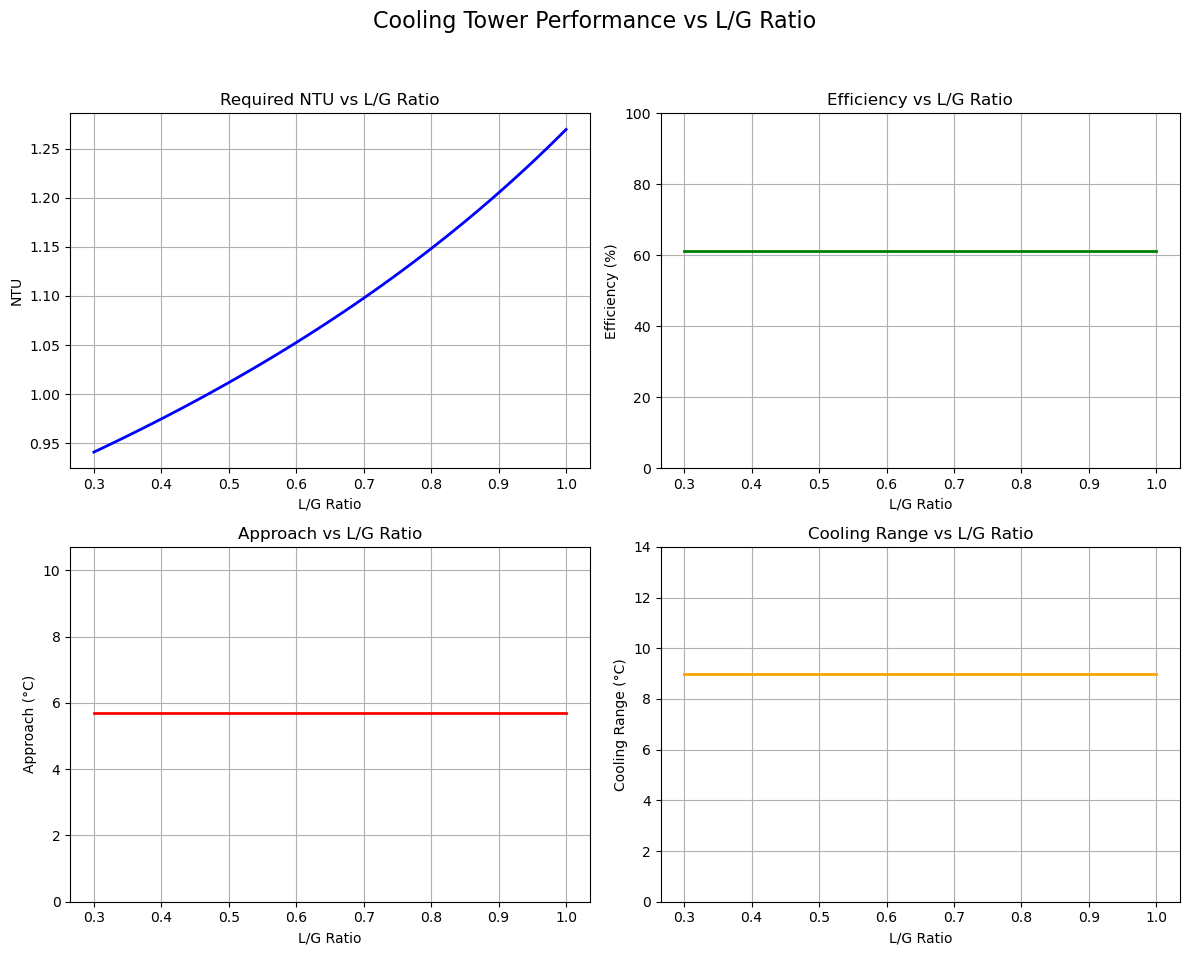

In [5]:
num_points = 50
start_val = 0.3
end_val = 1.0
LG_values = [start_val + i * (end_val - start_val) / (num_points - 1) for i in range(num_points)]

ntu_results = []
approach_results = []
range_results = []
efficiency_results = []

print("Running parametric study across L/G ratios...")

for lg in LG_values:
    # Recalculate integrands for this specific L/G ratio
    integrands = []
    valid = True
    for T_w in temperatures:
        sat_air = SI.state("DBT", T_w + 273.15, "RH", 1.0, P_atm)
        Hs = sat_air[1]
        
        # Energy balance using current L/G
        Ha = Ha_inlet + (lg * Cp_water * (T_w - T_cold))
        
        driving_force = Hs - Ha
        # If driving force becomes zero or negative, the cooling process is physically impossible
        if driving_force <= 0:
            valid = False
            break
            
        integrands.append(1.0 / driving_force)
        
    if valid:
        integrands_cp = [Cp_water * val for val in integrands]
        NTU_val = delta_T * (sum(integrands_cp) - 0.5 * integrands_cp[0] - 0.5 * integrands_cp[-1])
    else:
        NTU_val = float('nan')  # When matplotlib sees a NaN value, it simply skips drawing a line
        
    # Approach, Range, and Efficiency depend on the fixed temperatures in our current model, 
    # but we calculate them here to fulfill the requirement for all 4 plots.
    appr = T_cold - WBT_inlet
    r_T = T_hot - T_cold
    eff = (r_T / (r_T + appr)) * 100
    
    ntu_results.append(NTU_val)
    approach_results.append(appr)
    range_results.append(r_T)
    efficiency_results.append(eff)

# --- Plotting our Results ---
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Cooling Tower Performance vs L/G Ratio', fontsize=16)

# 1. NTU Plot
axs[0, 0].plot(LG_values, ntu_results, color='blue', linewidth=2)
axs[0, 0].set_title('Required NTU vs L/G Ratio')
axs[0, 0].set_xlabel('L/G Ratio')
axs[0, 0].set_ylabel('NTU')
axs[0, 0].grid(True)

# 2. Efficiency Plot
axs[0, 1].plot(LG_values, efficiency_results, color='green', linewidth=2)
axs[0, 1].set_title('Efficiency vs L/G Ratio')
axs[0, 1].set_xlabel('L/G Ratio')
axs[0, 1].set_ylabel('Efficiency (%)')
axs[0, 1].set_ylim(0, 100)
axs[0, 1].grid(True)

# 3. Approach Plot
axs[1, 0].plot(LG_values, approach_results, color='red', linewidth=2)
axs[1, 0].set_title('Approach vs L/G Ratio')
axs[1, 0].set_xlabel('L/G Ratio')
axs[1, 0].set_ylabel('Approach (°C)')
axs[1, 0].set_ylim(0, max(approach_results) + 5)
axs[1, 0].grid(True)

# 4. Cooling Range Plot
axs[1, 1].plot(LG_values, range_results, color='orange', linewidth=2)
axs[1, 1].set_title('Cooling Range vs L/G Ratio')
axs[1, 1].set_xlabel('L/G Ratio')
axs[1, 1].set_ylabel('Cooling Range (°C)')
axs[1, 1].set_ylim(0, max(range_results) + 5)
axs[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Analysis of the L/G Ratio Parametric Study

By plotting our four key variables across an $L/G$ ratio from $0.3$ to $1.0$, we can observe how the design requirements for our cooling tower change based on the proportion of water to air:

1.  **Required NTU:** As we increase the $L/G$ ratio (meaning we have more water relative to the amount of air), the driving force for cooling $(H_s - H_a)$ decreases. Consequently, our required NTU curve climbs exponentially. This indicates we need a significantly larger, more capable cooling tower to achieve the exact same cooling effect when we push more water through the same volume of air.
2.  **Approach, Cooling Range, & Efficiency:** Because our model holds the inlet and outlet water temperatures constant (to determine the required tower size for a fixed job), these three metrics plot as flat, horizontal lines. This perfectly visualizes that if our process temperatures are fixed, the tower's theoretical efficiency doesn't change, but the physical size of the tower (NTU) needed to achieve it changes drastically based on our $L/G$ ratio!